# ARYA Masterclass Demo (OpenEO + AGERA5 + Gaussian DVI Model)

This notebook is a teaching-friendly version of the ARYA workflow.
It runs a light one-season and one-oblast OpenEO demo, shows how to fit the DVI-GDD Gaussian model by oblasts, and explains how to scale to the full country.

## 1) Setup and Demo Configuration

- `RUN_REMOTE_DEMO = True`: run one-season remote extraction (fast demo).
- `RUN_REMOTE_DEMO = False`: use existing cached CSV outputs only.
- Full production range can be switched to `2021-01-01` .. `2021-07-30` in one place.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

RUN_REMOTE_DEMO = True
DEMO_DATE = '2021-05-25'  # one-day class demo date
FULL_START = '2021-01-01'
FULL_END = '2021-07-30'

BASE_DIR = Path('.').resolve()
DATA_GEOJSON = BASE_DIR.parent / 'data' / 'UKRAINE_level1_oblast.geojson'
OUT_DIR = BASE_DIR / 'outputs' / 'notebook_demo'
OUT_DIR.mkdir(parents=True, exist_ok=True)

DVI_CSV = OUT_DIR / 'dvi' / 'timeseries.csv'
TMEAN_CSV = OUT_DIR / 'agera5_tmean' / 'timeseries.csv'
GAUSS_PARAMS_CSV = OUT_DIR / 'gaussian_fit_params.csv'
GAUSS_SERIES_CSV = OUT_DIR / 'gaussian_fit_timeseries.csv'

COEFF_CSV = BASE_DIR.parent / 'data' / 'coefficients_PW.csv'
YIELD_SERIES_CSV = OUT_DIR / 'yield_timeseries.csv'
YIELD_OBLAST_CSV = OUT_DIR / 'yield_by_oblast.csv'

print('Base dir:', BASE_DIR)
print('GeoJSON:', DATA_GEOJSON)

Base dir: /home/kate/worldcereal-yield/Ukraine
GeoJSON: /home/kate/worldcereal-yield/data/UKRAINE_level1_oblast.geojson


## 2) Load and Visualize Oblasts

Rows: 28
Columns: ['num_ID', 'NAME_1', 'geometry']


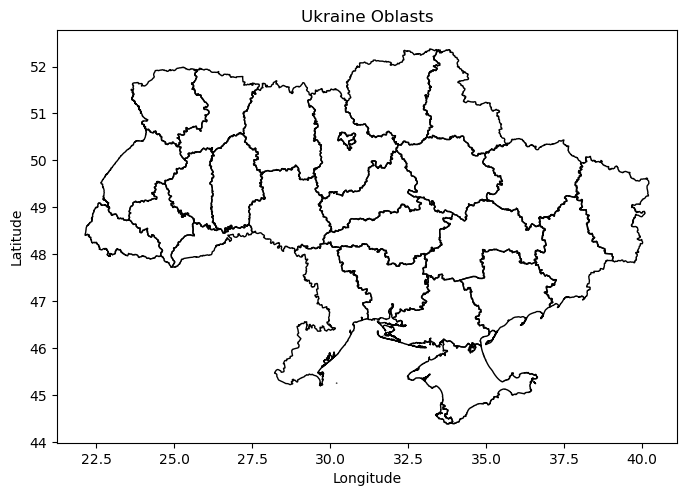

In [3]:
gdf = gpd.read_file(DATA_GEOJSON)
if gdf.crs is None:
    gdf = gdf.set_crs('EPSG:4326')
else:
    gdf = gdf.to_crs('EPSG:4326')

print('Rows:', len(gdf))
print('Columns:', list(gdf.columns))

ax = gdf.plot(figsize=(8, 8), edgecolor='black', facecolor='none')
ax.set_title('Ukraine Oblasts')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

## 3) OpenEO Processing (One-Season Demo)

In this block, we run the core ARYA preprocessing chain on a single season and one oblast to keep class runtime low while preserving the full production logic.

### 1. MODIS DVI (`B02 - B01`)
DVI is computed from MODIS surface reflectance as: DVI = NIR-RED = B02-B01.
Healthy vegetation generally has higher NIR than RED reflectance, so DVI tracks canopy vigor.

### 2. Crop type filtering with WorldCereal
`ESA_WORLDCEREAL_WINTERCEREALS` provides crop classification at 10 m. We use it to isolate winter wheat signal.
MODIS is coarser than 10 m, so we spatially average the 10 m classification into each MODIS pixel, obtaining wheat fraction (%).

### 3. Why use threshold >= 50?
Important: this threshold is on wheat fraction (not DVI). Pixels with >=50% wheat are retained to reduce mixed-pixel contamination and keep a crop-specific signal, aligned with the ARYA approach (Franch et al., 2021).

### 4. AGERA5 temperature
AGERA5 is a daily agro-meteorological dataset (0.1°), produced for agricultural modelling. We use `temperature-mean` as thermal forcing to compute GDD and normalize phenological progression.

### 5. Aggregate by oblast
Both wheat-masked DVI and AGERA5 temperature are aggregated by oblast polygons and exported as CSV.

In [3]:
if RUN_REMOTE_DEMO:
    import openeo

    c = openeo.connect('openeo.vito.be').authenticate_oidc(provider_id='terrascope')

    temporal_extent = [FULL_START, FULL_END]
    
    # Keep payload light for robust class runs
    gdf_job = gdf[gdf["NAME_1"].isin(["Kherson"])][["num_ID", "NAME_1", "geometry"]].copy()
    minx, miny, maxx, maxy = gdf_job.total_bounds
    spatial_extent = {
        'west': float(minx),
        'south': float(miny),
        'east': float(maxx),
        'north': float(maxy),
        'crs': 4326
    }
    geoms = gdf_job.__geo_interface__

    #spatial_extent = {'west': 22, ‘south': 44, 'east': 41, 'north': 53, 'crs': 4326}  # In case you want to run all Ukraine

    modis = c.load_collection('MODIS', spatial_extent=spatial_extent, temporal_extent=temporal_extent, bands=['B01', 'B02'])
    red = modis.band('B01')
    nir = modis.band('B02')
    dvi = nir - red

    winter = c.load_collection(
        'ESA_WORLDCEREAL_WINTERCEREALS',
        temporal_extent=['2021-01-01', '2021-12-31'],
        spatial_extent=spatial_extent,
        bands=['CLASSIFICATION']
    )
    winter_pct = winter.band('CLASSIFICATION').apply(lambda x: (x == 100) * 100)
    winter_static = winter_pct.reduce_dimension(dimension='t', reducer='first')
    winter_pct_modis = winter_static.resample_cube_spatial(target=dvi, method='average')
    wheat_mask = winter_pct_modis >= 50
    dvi_wheat = dvi.mask(~wheat_mask)

    """# Keep payload light for robust class runs
    gdf_job = gdf[['num_ID', 'NAME_1', 'geometry']].copy()
    geoms = gdf_job.__geo_interface__"""

    dvi_oblast = dvi_wheat.aggregate_spatial(geometries=geoms, reducer='mean')

    tmean = c.load_collection('AGERA5', spatial_extent=spatial_extent, temporal_extent=temporal_extent, bands=['temperature-mean'])
    tmean_oblast = tmean.aggregate_spatial(geometries=geoms, reducer='mean')

    (OUT_DIR / 'dvi').mkdir(parents=True, exist_ok=True)
    (OUT_DIR / 'agera5_tmean').mkdir(parents=True, exist_ok=True)
    (OUT_DIR / 'wheat_modis').mkdir(parents=True, exist_ok=True)
    (OUT_DIR / 'wheat_50').mkdir(parents=True, exist_ok=True)

    job_dvi = dvi_oblast.execute_batch(title='ARYA demo DVI by oblast', out_format='CSV')
    job_tmp = tmean_oblast.execute_batch(title='ARYA demo AGERA5 by oblast', out_format='CSV')
    job_winter = winter_pct_modis.execute_batch(title="Winter wheat fraction resampled to MODIS", out_format="GTiff")
    job_mask = wheat_mask.execute_batch(title="Winter wheat mask >=50%", out_format="GTiff")

    print('DVI job:', job_dvi.job_id)
    print('Tmean job:', job_tmp.job_id)
    print('Wheat job:', job_winter.job_id)
    print('Mask job:', job_mask.job_id)

    job_dvi.start_and_wait()
    job_tmp.start_and_wait()
    job_winter.start_and_wait()
    job_mask.start_and_wait()

    job_dvi.download_results(target=OUT_DIR / 'dvi')
    job_tmp.download_results(target=OUT_DIR / 'agera5_tmean')
    job_winter.download_results(target=OUT_DIR / 'wheat_modis')
    job_mask.download_results(target=OUT_DIR / 'wheat_50')

    print('Demo CSV exported to', OUT_DIR)
else:
    print('RUN_REMOTE_DEMO=False: expecting cached CSV files in', OUT_DIR)

Authenticated using refresh token.
0:00:00 Job 'j-2605041121114fec91314fa1c445f944': send 'start'
0:01:18 Job 'j-2605041121114fec91314fa1c445f944': queued (progress 0%)
0:01:23 Job 'j-2605041121114fec91314fa1c445f944': queued (progress 0%)
0:01:30 Job 'j-2605041121114fec91314fa1c445f944': queued (progress 0%)
0:01:38 Job 'j-2605041121114fec91314fa1c445f944': queued (progress 0%)
0:01:54 Job 'j-2605041121114fec91314fa1c445f944': running (progress 7.8%)
0:02:07 Job 'j-2605041121114fec91314fa1c445f944': running (progress 9.6%)
0:02:23 Job 'j-2605041121114fec91314fa1c445f944': running (progress 11.8%)
0:02:43 Job 'j-2605041121114fec91314fa1c445f944': running (progress 14.2%)
0:03:09 Job 'j-2605041121114fec91314fa1c445f944': running (progress 17.3%)
0:03:42 Job 'j-2605041121114fec91314fa1c445f944': running (progress 20.9%)
0:04:22 Job 'j-2605041121114fec91314fa1c445f944': running (progress 24.9%)
0:05:09 Job 'j-2605041121114fec91314fa1c445f944': running (progress 29.1%)
0:06:11 Job 'j-26050

/tmp/ipykernel_2698730/2630742303.py:68: UserDeprecationWarning: Call to deprecated method download_results. (Instead use `BatchJob.get_results` and the more flexible download functionality of `JobResults`) -- Deprecated since version 0.4.10.
  job_dvi.download_results(target=OUT_DIR / 'dvi')
/home/kate/.conda/envs/arya_openeo/lib/python3.12/site-packages/openeo/rest/job.py:199: UserDeprecationWarning: Call to deprecated method get_result. (Use `BatchJob.get_results` instead.) -- Deprecated since version 0.4.10.
  return self.get_result().download_files(target)
/home/kate/.conda/envs/arya_openeo/lib/python3.12/site-packages/openeo/rest/job.py:203: UserDeprecationWarning: Call to deprecated class _Result. (Use `JobResults` instead) -- Deprecated since version 0.4.10.
  return _Result(self)
/tmp/ipykernel_2698730/2630742303.py:69: UserDeprecationWarning: Call to deprecated method download_results. (Instead use `BatchJob.get_results` and the more flexible download functionality of `JobRes

Demo CSV exported to /home/kate/worldcereal-yield/Ukraine/outputs/notebook_demo


OUT_DIR = /home/kate/worldcereal-yield/Ukraine/outputs/notebook_demo
Resolved OUT_DIR = /home/kate/worldcereal-yield/Ukraine/outputs/notebook_demo
dvi
agera5_tmean
wheat_modis
wheat_50
gaussian_fit_params.csv
gaussian_fit_timeseries.csv
yield_timeseries.csv
yield_by_oblast.csv


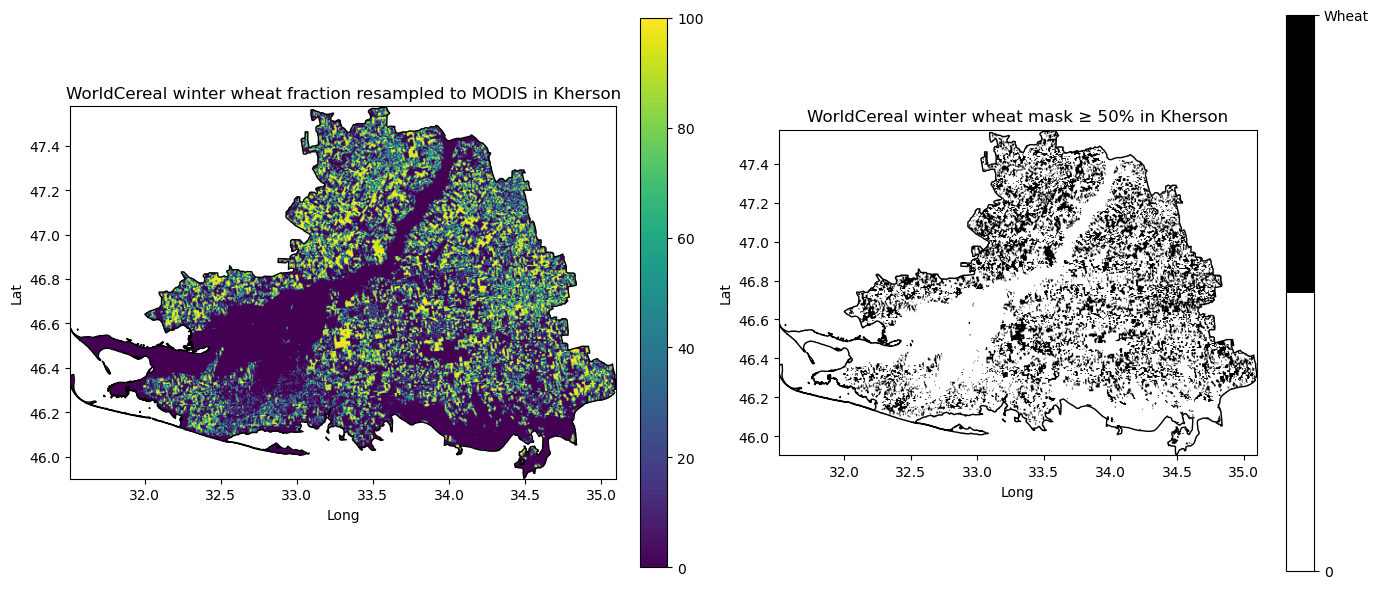

In [4]:
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path
from rasterio.mask import mask
from rasterio.plot import plotting_extent
import matplotlib.colors as mcolors

print("OUT_DIR =", OUT_DIR)
print("Resolved OUT_DIR =", OUT_DIR.resolve())

for p in OUT_DIR.iterdir():
    print(p.name)
    
kherson = gdf[gdf["NAME_1"].isin(["Kherson"])][["num_ID", "NAME_1", "geometry"]].copy()
winter_tif = OUT_DIR / "wheat_modis" / "openEO.tif"
mask_tif = OUT_DIR / "wheat_50" / "openEO.tif"

kherson_geom = kherson.geometry.values

with rasterio.open(winter_tif) as src:
    winter_crs = src.crs
    
if kherson.crs != winter_crs:
    kherson = kherson.to_crs(winter_crs)

with rasterio.open(winter_tif) as src:
    winter_crop, winter_transform = mask(src, kherson_geom, crop=True, filled=False)
    winter_arr = winter_crop[0].astype(float)
    winter_arr[winter_crop[0].mask] = np.nan

with rasterio.open(mask_tif) as src:
    mask_crop, mask_transform = mask(src, kherson_geom, crop=True, filled=False)
    mask_arr = mask_crop[0].astype(float)
    mask_arr[mask_crop[0].mask] = np.nan

winter_extent = plotting_extent(winter_arr, winter_transform)
mask_extent = plotting_extent(mask_arr, mask_transform)
    
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im1 = axes[0].imshow(winter_arr, cmap="viridis", extent=winter_extent, origin="upper")
kherson.boundary.plot(ax=axes[0], edgecolor="black", linewidth=1)
axes[0].set_title("WorldCereal winter wheat fraction resampled to MODIS in Kherson")
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

cmap = mcolors.ListedColormap(["white", "black"])
im2 = axes[1].imshow(mask_arr, cmap=cmap, extent=mask_extent, origin="upper", vmin=0, vmax=1)
kherson.boundary.plot(ax=axes[1], edgecolor="black", linewidth=1)
axes[1].set_title("WorldCereal winter wheat mask ≥ 50% in Kherson")
cbar = plt.colorbar(im2, ax=axes[1], ticks=[0, 1])
cbar.set_ticklabels(["0", "Wheat"])

for ax in axes:
    ax.set_xlabel("Long")
    ax.set_ylabel("Lat")

plt.tight_layout()
plt.show()

## 4) Build GDD and Fit Gaussian DVI Model

We model canopy evolution in **thermal time** instead of calendar time. This follows the phenology principle from McMaster & Wilhelm (1997): development is primarily driven by accumulated temperature.

### Why GDD is important
GDD helps normalize crop evolution across years/regions with different weather trajectories. Two seasons can reach similar phenological stages at similar accumulated thermal time, even on different calendar dates.

### GDD equations used
$$\mathrm{GDD}_{day}=\max\!\left(T_{mean,day}-T_{base},\,0\right)$$
$$\mathrm{GDD}_{accum}(d)=\sum_{i=1}^{d}\mathrm{GDD}_{day,i}$$

Rules in this notebook:
- `Tbase = 0`
- `D = median(last 15 DVI days)`

### Gaussian DVI model
$$\mathrm{DVI}(d)=A\cdot\exp\left(-\frac{1}{2}\left(\frac{\mathrm{GDD}_{accum}(d)-B}{C}\right)^2\right)+D$$

Interpretation:
- **A**: amplitude above baseline (signal strength / canopy vigor). Often related to yield potential.
- **B**: thermal-time location of peak greenness (timing).
- **C**: curve width in thermal time (effective duration of active canopy).
- **D**: baseline/background component (soil/residual vegetation), provided as value 0.11.

We report `R2` and `RMSE` to evaluate fit quality by oblast.

In [5]:
from scipy.optimize import curve_fit

if not DVI_CSV.exists() or not TMEAN_CSV.exists():
    raise FileNotFoundError('Missing demo CSV files. Run remote block or place cached files first.')

dvi_df = pd.read_csv(DVI_CSV).rename(columns={'band_unnamed': 'dvi'})
tmp_df = pd.read_csv(TMEAN_CSV).rename(columns={'temperature-mean': 'tmean'})
print(pd.read_csv(DVI_CSV).columns.tolist())
print(pd.read_csv(TMEAN_CSV).columns.tolist())

dvi_df['date'] = pd.to_datetime(dvi_df['date'])
tmp_df['date'] = pd.to_datetime(tmp_df['date'])

df = dvi_df.merge(tmp_df[['date', 'feature_index', 'tmean']], on=['date', 'feature_index'], how='inner')

# Optional unit guard (some backends serve Kelvin)
if df['tmean'].median() > 100:
    df['tmean'] = df['tmean'] / 100.0 - 273.15

gdf_job = gdf[gdf["NAME_1"].isin(["Kherson"])][["num_ID", "NAME_1", "geometry"]].copy()
feature_map = gdf_job[['num_ID', 'NAME_1', 'geometry']].reset_index(drop=True).copy()
feature_map['feature_index'] = feature_map.index
feature_map['geometry_wkt'] = feature_map.geometry.to_wkt()
print(feature_map[['num_ID', 'NAME_1']].drop_duplicates().sort_values('num_ID').to_string(index=False))

def gauss_model(x, a, b, c, d):
    return a * np.exp(-0.5 * ((x - b) / c) ** 2) + d

params_rows = []
series_rows = []

for fidx, grp in df.groupby('feature_index'):
    grp = grp.sort_values('date').copy()
    if len(grp) < 20:
        continue

    d_baseline = 0.11
    tbase = 0.0
    grp['gdd_day'] = np.maximum(grp['tmean'] - tbase, 0.0)
    grp['gdd_accum'] = grp['gdd_day'].cumsum()

    x = grp['gdd_accum'].to_numpy(float)
    y = grp['dvi'].to_numpy(float)
    if np.nanstd(y) < 1e-8:
        continue

    a0 = float(max(np.nanmax(y) - d_baseline, 0.01))
    b0 = float(x[np.nanargmax(y)])
    c0 = float(max((np.nanmax(x) - np.nanmin(x)) / 4.0, 1.0))
    print("a0, b0, c0, d:", a0, b0, c0, d_baseline)

    try:
        popt, _ = curve_fit(
            lambda xx, a, b, c: gauss_model(xx, a, b, c, d_baseline),
            x, y, p0=[a0, b0, c0],
            bounds=([0.0, np.nanmin(x)-1000.0, 1e-3], [1.0, np.nanmax(x)+1000.0, 10000.0]),
            maxfev=20000
        )
    except Exception:
        continue

    a_fit, b_fit, c_fit = [float(v) for v in popt]
    y_hat = gauss_model(x, a_fit, b_fit, c_fit, d_baseline)
    resid = y - y_hat
    rmse = float(np.sqrt(np.nanmean(resid ** 2)))
    ss_res = float(np.nansum(resid ** 2))
    ss_tot = float(np.nansum((y - np.nanmean(y)) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan

    match = feature_map.loc[feature_map['feature_index'] == int(fidx)]
    print("n matches for feature", fidx, "=", len(match))
    if match.empty:
        print(f"No feature_map match for feature_index {fidx}")
        continue
    info = match.iloc[0]

    params_rows.append({
        'feature_index': int(fidx),
        'num_ID': info['num_ID'],
        'oblast_name': info['NAME_1'],
        'geometry_wkt': info['geometry_wkt'],
        'A': a_fit, 'B': b_fit, 'C': c_fit, 'D': d_baseline,
        'R2': r2, 'RMSE': rmse, 'n_obs': len(grp)
    })

    grp['dvi_pred'] = y_hat
    grp['num_ID'] = info['num_ID']
    grp['oblast_name'] = info['NAME_1']
    grp['geometry_wkt'] = info['geometry_wkt']
    grp['A'] = a_fit
    grp['B'] = b_fit
    grp['C'] = c_fit
    grp['D'] = d_baseline

    series_rows.append(grp[['date','feature_index','num_ID','oblast_name','geometry_wkt','dvi','tmean','gdd_day','gdd_accum','dvi_pred','A','B','C','D']])

params_df = pd.DataFrame(params_rows)
if not params_df.empty:
    params_df = params_df.sort_values('feature_index')
else:
    print("No fitted parameters produced.")
series_df = pd.concat(series_rows, axis=0).sort_values(['feature_index','date']) if series_rows else pd.DataFrame()

params_df.to_csv(GAUSS_PARAMS_CSV, index=False)
series_df.to_csv(GAUSS_SERIES_CSV, index=False)

print('Saved:', GAUSS_PARAMS_CSV)
print('Saved:', GAUSS_SERIES_CSV)
params_df.head()

['date', 'feature_index', 'band_unnamed']
['date', 'feature_index', 'temperature-mean']
num_ID  NAME_1
    11 Kherson
a0, b0, c0, d: 0.2268010403615262 864.0929292929324 596.6928367003379 0.11
n matches for feature 0 = 1
Saved: /home/kate/worldcereal-yield/Ukraine/outputs/notebook_demo/gaussian_fit_params.csv
Saved: /home/kate/worldcereal-yield/Ukraine/outputs/notebook_demo/gaussian_fit_timeseries.csv


,feature_index,num_ID,oblast_name,geometry_wkt,A,B,C,D,R2,RMSE,n_obs
0,0,11,Kherson,"MULTIPOLYGON (((31.971251 46.19875, 31.969305 ...",0.24448,906.248825,366.891554,0.11,0.838218,0.032667,210


## 5) Performance Plots

Recommended performance visuals for class:
1. **Performance map by oblast**: `R2` and `RMSE` to show spatial reliability.
2. **Observed vs predicted DVI through GDD accumulation**: core phenology fit view.
3. **DVI and temperature over time**: links meteorological forcing with canopy response.
4. **DVI forecast and performance panel**: show short-range projected DVI from fitted Gaussian and metrics (`R2`, `RMSE`, `A`, `B`, `C`, `D`).

### Showcase oblast: Kherson
Perform Gaussian fitting to retrieve parameters for yield modeling.

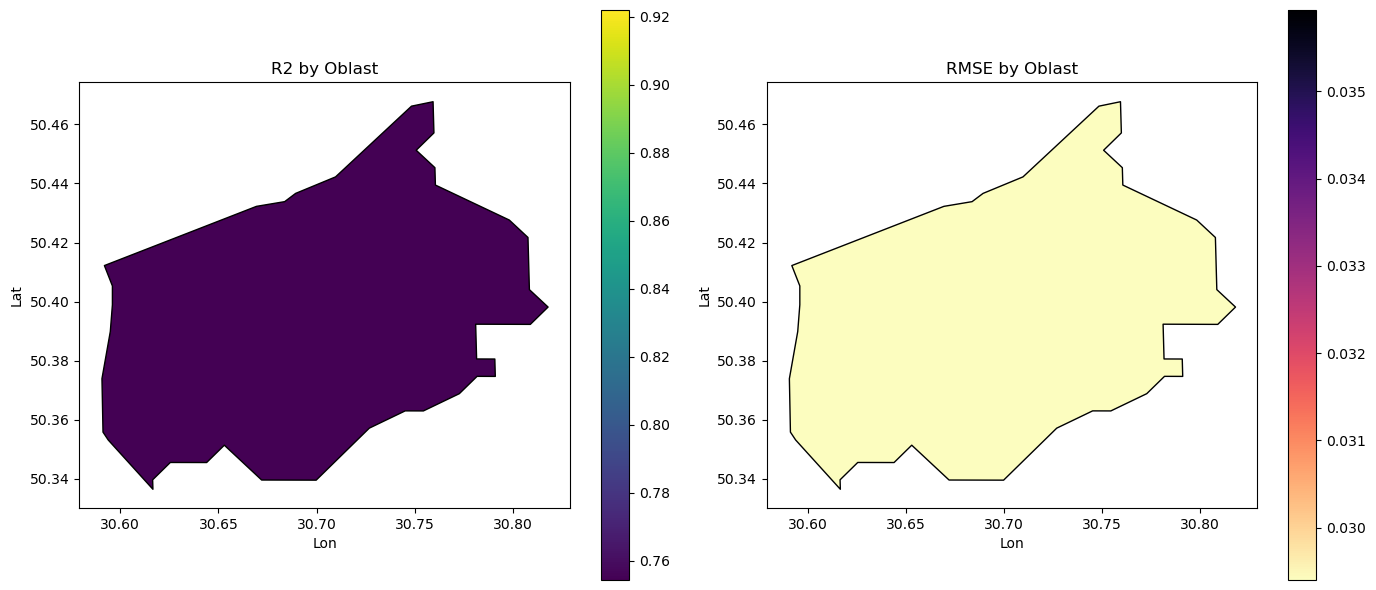

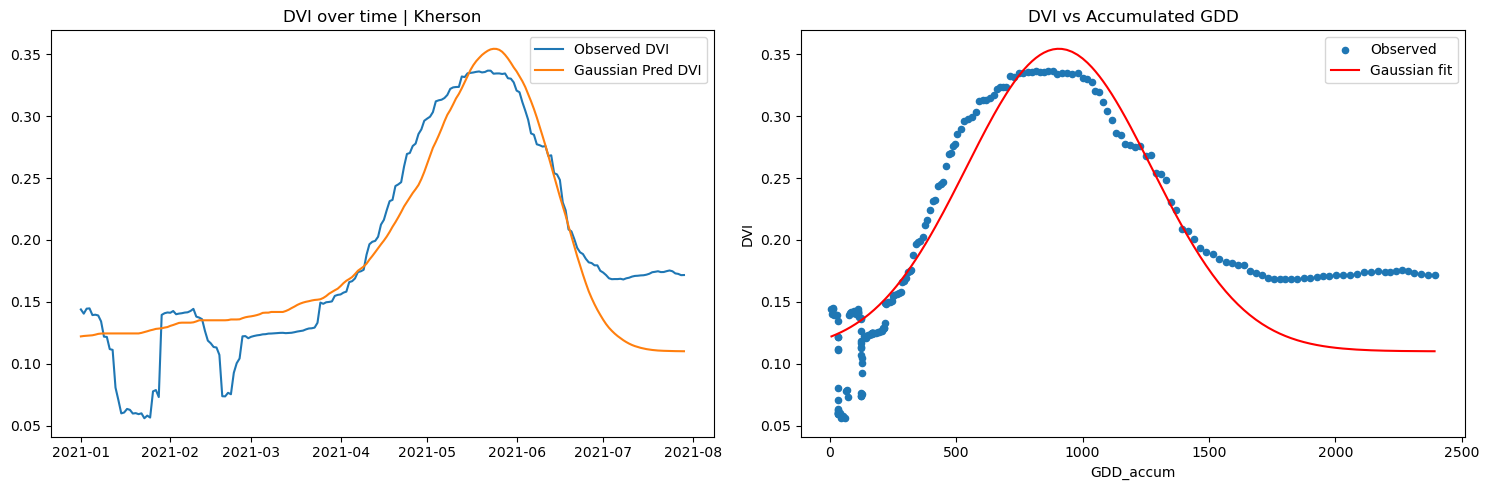

In [6]:
if params_df.empty or series_df.empty:
    print('No fitted rows available yet.')
else:
    map_df = gdf.reset_index(drop=True).copy()
    map_df['feature_index'] = map_df.index
    map_df = map_df.merge(params_df[['feature_index','R2','RMSE']], on='feature_index', how='left')

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    map_df.plot(column='R2', cmap='viridis', legend=True, ax=axes[0], edgecolor='black')
    axes[0].set_title('R2 by Oblast')
    map_df.plot(column='RMSE', cmap='magma_r', legend=True, ax=axes[1], edgecolor='black')
    axes[1].set_title('RMSE by Oblast')
    for ax in axes:
        ax.set_xlabel('Lon')
        ax.set_ylabel('Lat')
    plt.tight_layout()
    plt.show()

    # Pick one oblast for detailed curves
    fidx = int(params_df.sort_values('R2', ascending=False).iloc[0]['feature_index'])
    one = series_df[series_df['feature_index'] == fidx].copy()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].plot(one['date'], one['dvi'], label='Observed DVI')
    axes[0].plot(one['date'], one['dvi_pred'], label='Gaussian Pred DVI')
    axes[0].set_title(f"DVI over time | {one['oblast_name'].iloc[0]}")
    axes[0].legend()

    axes[1].scatter(one['gdd_accum'], one['dvi'], s=20, label='Observed')
    axes[1].plot(one['gdd_accum'], one['dvi_pred'], color='red', label='Gaussian fit')
    axes[1].set_title('DVI vs Accumulated GDD')
    axes[1].set_xlabel('GDD_accum')
    axes[1].set_ylabel('DVI')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 6) Steps in a nutshell

1. **Geography layer**: oblast polygons and IDs (`num_ID`, `NAME_1`).
2. **Crop layer**: WorldCereal wheat mask from 10m to MODIS percentage.
3. **Signal layer**: DVI from MODIS (`B02 - B01`) and masking to wheat-only pixels.
4. **Climate layer**: AGERA5 `temperature-mean`, transformed to daily and accumulated GDD.
5. **Model layer**: Gaussian DVI response as a function of accumulated GDD.
6. **Performance layer**: R2/RMSE by oblast to discuss model behavior.

Later, you can append your yield-prediction stage by multiplying fitted Gaussian coefficients with your external yield coefficients.

## 7) Apply ARYA Yield Model

This block merges Gaussian components with external yield coefficients from `data/coefficients_PW.csv`.

Model used:
$$\mathrm{yield}=a\cdot A+b\cdot C$$

Where:
- `A`, `C`: Gaussian components from fitted DVI-GDD model.
- `a`, `b`: coefficients by `OBLAST` and `DOY` from the coefficient table.


In [9]:
if series_df.empty:
    print('No Gaussian series available yet. Run section 4 first.')
else:
    coef_df = pd.read_csv(COEFF_CSV).copy()
    # Remove index-like helper columns from CSV exports
    coef_df = coef_df.loc[:, ~coef_df.columns.str.contains('^Unnamed')]

    required_cols = {'DOY', 'OBLAST', 'C1_peak', 'C2_width'}
    missing = required_cols.difference(set(coef_df.columns))
    if missing:
        raise KeyError(f'Missing coefficient columns: {sorted(missing)}')

    coef_df = coef_df.rename(columns={
        'OBLAST': 'num_ID',
        'DOY': 'doy',
        'C1_peak': 'a',
        'C2_width': 'b',
    })

    # Coeff file may contain multiple years; use mean coefficient per (oblast, doy).
    coef_use = coef_df.groupby(['num_ID', 'doy'], as_index=False)[['a', 'b']].mean()

    ys = series_df.copy()
    ys['date'] = pd.to_datetime(ys['date'])
    ys['doy'] = ys['date'].dt.dayofyear.astype(int)

    # Normalize ID dtype for robust joins
    ys['num_ID'] = pd.to_numeric(ys['num_ID'], errors='coerce').astype('Int64')
    coef_use['num_ID'] = pd.to_numeric(coef_use['num_ID'], errors='coerce').astype('Int64')

    yield_df = ys.merge(coef_use, on=['num_ID', 'doy'], how='left')
    yield_df['yield_model'] = yield_df['a'] * yield_df['A'] + yield_df['b'] * yield_df['C']

    matched = yield_df['yield_model'].notna().sum()
    total = len(yield_df)
    print(f'Matched coefficient rows: {matched}/{total}')

    keep_cols = [
        'date', 'doy', 'feature_index', 'num_ID', 'oblast_name',
        'A', 'B', 'C', 'D', 'a', 'b', 'yield_model'
    ]
    keep_cols = [c for c in keep_cols if c in yield_df.columns]
    yield_out = yield_df[keep_cols].copy().sort_values(['num_ID', 'date'])

    # Daily value by oblast and season summary
    by_oblast = yield_out.groupby(['num_ID', 'oblast_name'], as_index=False)['yield_model'].mean()

    yield_out.to_csv(YIELD_SERIES_CSV, index=False)
    by_oblast.to_csv(YIELD_OBLAST_CSV, index=False)

    print('Saved:', YIELD_SERIES_CSV)
    print('Saved:', YIELD_OBLAST_CSV)

    start_date = pd.to_datetime("2021-05-10", utc=True)
    end_date   = pd.to_datetime("2021-05-16", utc=True)

    yield_out_range = yield_out[(yield_out["date"] >= start_date) & (yield_out["date"] < end_date)]
    by_oblast_range = (yield_out_range.groupby(["num_ID", "oblast_name"], as_index=False)["yield_model"].mean())
    
    display(yield_out_range.head(5))
    display(by_oblast_range.head(1))


Matched coefficient rows: 73/210
Saved: /home/kate/worldcereal-yield/Ukraine/outputs/notebook_demo/yield_timeseries.csv
Saved: /home/kate/worldcereal-yield/Ukraine/outputs/notebook_demo/yield_by_oblast.csv


,date,doy,feature_index,num_ID,oblast_name,A,B,C,D,a,b,yield_model
129,2021-05-10 00:00:00+00:00,130,0,11,Kherson,0.24448,906.248825,366.891554,0.11,3.259170,-0.000236,0.710150
130,2021-05-11 00:00:00+00:00,131,0,11,Kherson,0.24448,906.248825,366.891554,0.11,3.908756,-0.000807,0.659413
131,2021-05-12 00:00:00+00:00,132,0,11,Kherson,0.24448,906.248825,366.891554,0.11,3.018413,-0.000190,0.668387
132,2021-05-13 00:00:00+00:00,133,0,11,Kherson,0.24448,906.248825,366.891554,0.11,1.452064,0.000854,0.668463
133,2021-05-14 00:00:00+00:00,134,0,11,Kherson,0.24448,906.248825,366.891554,0.11,-0.333374,0.002156,0.709499


,num_ID,oblast_name,yield_model
0,11,Kherson,0.687316
